In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
from functions import get_user_number_from_config, data_from_data_sink

In [ ]:
INSERT_ID = "ceb80223ad505d83835c9c05e24ece5a1f3ad012a7dd64c1fd30c0e94d7788df"

# Korrigierte SQL-Abfrage (WEHRE → WHERE)
query = f"SELECT user_number FROM dim_user WHERE user_id = '{INSERT_ID}' ORDER BY user_number DESC LIMIT 1;"

# Hole Ergebnis aus Datenbank
user_df = data_from_data_sink(query)
print("Abfrageergebnis:", user_df)

# Prüfen, ob Ergebnis vorhanden ist
if not user_df.empty:
    # Nimm den letzten user_number-Wert
    last_user_number = int(user_df["user_number"].iloc[-1])

    # Schreibe ihn in die Datei (überschreibt Inhalt)
    with open("data/cur_user_selected.txt", "w", encoding="utf-8") as f:
        f.write(str(last_user_number))

    print(f"✅ User-Nummer {last_user_number} erfolgreich gespeichert.")
else:
    print("⚠️ Keine Daten gefunden – Datei nicht verändert.")



Abfrageergebnis:    user_number
0            4
✅ User-Nummer 4 erfolgreich gespeichert.


/Users/dave/Desktop/BIPM/WHO_AM_I/sports-buddies/sports-buddies/functions.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [ ]:
user = get_user_number_from_config()
print(user)

11


In [264]:
query = f"""
SELECT 
    steps_avg,
    sleep_hours_avg,
    sleep_hours_std,
    sleep_hours_goal,
    sleep_wakeups_avg,
    tot_wellness_score
FROM dim_health
WHERE user_number = {user}
Order by entity_id DESC
LIMIT 1;
"""
df_health = data_from_data_sink(query)
print(df_health)

   steps_avg  sleep_hours_avg  sleep_hours_std  sleep_hours_goal  \
0   342471.0              NaN              NaN               7.0   

   sleep_wakeups_avg  tot_wellness_score  
0                NaN                0.58  


/Users/dave/Desktop/BIPM/WHO_AM_I/sports-buddies/sports-buddies/functions.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [265]:
query = f"""
SELECT 
    at_id
FROM dim_health
WHERE user_number = {user}
ORDER BY entity_id DESC
LIMIT 1;
"""
at_id= data_from_data_sink(query)
print(at_id)
if at_id.empty == False and  at_id["at_id"][0] != None:
    
    at_id = int(at_id["at_id"][0])
    print(at_id)
    query = f"""
    SELECT *
    FROM dim_activity_times
    WHERE at_id = {at_id};
    """
    df_at = data_from_data_sink(query)
    at = True
    print(df_at)
else: 
    at = False

/Users/dave/Desktop/BIPM/WHO_AM_I/sports-buddies/sports-buddies/functions.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


   at_id
0     10
10
    id  at_id   weekday      day_part     steps  sleep_hours  workload_score
0  377     10  Thursday  Night\n(0–4)  342471.0          0.0             0.6


/Users/dave/Desktop/BIPM/WHO_AM_I/sports-buddies/sports-buddies/functions.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [266]:
query = f"""
SELECT 
   fl_workouts_pw,
   fl_cardio_min_pw,
   pa_t1,
    pa_t2,
    pa_t3,
    pa_t4,
    fitness_type_endurence,
    fitness_type_strength,
    fitness_type_flexibility,
    fitness_type_relaation,
    motivation_type,
    sc_strava_social_score,
    sc_strava_event_dog
FROM dim_strava
WHERE user_number = {user}
Order by entity_id DESC
LIMIT 1;
"""
df_strava = data_from_data_sink(query)

/Users/dave/Desktop/BIPM/WHO_AM_I/sports-buddies/sports-buddies/functions.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [267]:
df_user = pd.concat([df_health.reset_index(drop = True),df_strava.reset_index(drop = True )], axis=1)

In [268]:
print(df_user)

   steps_avg  sleep_hours_avg  sleep_hours_std  sleep_hours_goal  \
0   342471.0              NaN              NaN               7.0   

   sleep_wakeups_avg  tot_wellness_score  fl_workouts_pw  fl_cardio_min_pw  \
0                NaN                0.58             3.6           224.998   

      pa_t1        pa_t2 pa_t3 pa_t4  fitness_type_endurence  \
0  Ride\n58  Workout\n18    NA    NA                0.809646   

   fitness_type_strength  fitness_type_flexibility  fitness_type_relaation  \
0               0.190354                       0.0                     0.0   

  motivation_type  sc_strava_social_score  sc_strava_event_dog  
0     Performance                     0.0                False  


In [269]:
if at:
    # Sortierung vorbereiten (vor dem Pivot!)
    order_day_part = [
        "Early Morning (4–8)",
        "Morning (8–12)",
        "Noon (12–16)",
        "Afternoon (16–20)",
        "Evening (20–24)",
        "Night (0–4)"
    ]
    df_at = df_at.pivot(index="day_part", columns="weekday", values="steps")
    print(df_at)

weekday       Thursday
day_part              
Night\n(0–4)  342471.0


In [270]:
order_day_part = [
    "Early Morning\n(4–8)",
    "Morning\n(8–12)",
    "Noon\n(12–16)",
    "Afternoon\n(16–20)",
    "Evening\n(20–24)",
    "Night\n(0–4)"
]

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_labels = ["MON", "TUE", "WED", "THU", "FRI", "SAT", "SUN"]

# Heatmap-Daten vorbereiten
if at:
    heatmap_data = df_at.reindex(index=order_day_part, columns=weekday_order).fillna(0)
else:
    heatmap_data = pd.DataFrame(0, index=order_day_part, columns=weekday_order)

# Bildgröße (8.4 cm x 4 cm in inch)
figsize_inch = (20 / 2.54, 7 / 2.54)

# Plot erstellen
plt.figure(figsize=figsize_inch, dpi=300)
sns.set_theme(style="white")

ax = sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=False,
    linewidths=0.3,
    linecolor='white',
    cbar=False,
    xticklabels=weekday_labels,
    yticklabels=False
)

plt.title("", fontsize=0, weight='bold')
plt.ylabel("Daytime", fontsize=15, fontweight='bold')
plt.xlabel("")
plt.xticks(rotation=0, fontsize=15, fontweight='bold')
plt.yticks(fontsize=4)

plt.tight_layout()
plt.savefig("images/charts/activity_heatmap.png", dpi=300, bbox_inches='tight')
plt.close()


In [271]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

labels = ["Strength", "Endurance", "Relaxation", "Flexibility"]
# Get the values for each fitness type (should be 4 values)
values = df_user[["fitness_type_strength", "fitness_type_endurence", "fitness_type_relaation", "fitness_type_flexibility"]].values.flatten().tolist()
# Replace None with 0
values = [0 if v is None else v for v in values]
print(values)
# Convert to percent
values = [v * 100 for v in values]
# Close the radar chart by repeating the first value at the end
values += values[:1]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')

ax.plot(angles, values, color="#28b463", linewidth=2)
ax.fill(angles, values, color="#28b463", alpha=0.3)

# Entferne Standard-Labels
ax.set_xticks([])

# Benutzerdefinierte Labels mit weißem Hintergrund
for angle, label in zip(angles[:-1], labels):
    ax.text(
        angle - np.pi / 20,  # Adjusted for better centering
        90,
        label,
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold',
        bbox=dict(facecolor='white', edgecolor='none', pad=2)
    )

ax.set_yticks(range(20, int(max(values)) + 21, 20))
ax.set_yticklabels([f'{y}%' for y in range(20, int(max(values)) + 21, 20)], fontsize=12, color='gray')
ax.set_ylim(0, int(max(values)) + 21)
ax.grid(color="#ccc", linestyle=":", linewidth=0.7)
ax.spines["polar"].set_color("#ccc")

plt.tight_layout()

# ✅ Speichern in 250x250 px
plt.savefig("images/charts/fitness_type.png", dpi=600, bbox_inches='tight')
plt.close()


[0.1903539128089452, 0.8096460871910548, 0.0, 0.0]


/var/folders/n9/9rvxcg4d1d15_3wh3wq9f0l40000gn/T/ipykernel_40552/1133942219.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_user["sleep_hours_avg"][0] = 0
/var/folders/n9/9rvxcg4d1d15_3wh3wq9f0l40000gn/T/ipykernel_40552/1133942219.py:

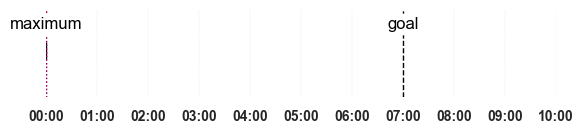

In [272]:
if pd.isna(df_user["sleep_hours_avg"][0]):
    df_user["sleep_hours_avg"][0] = 0
if pd.isna(df_user["sleep_hours_goal"][0]):
    df_user["sleep_hours_goal"][0] = 0
if pd.isna(df_user["sleep_hours_std"][0]):
    df_user["sleep_hours_std"][0] = 0

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


# Werte definieren

avg = df_user["sleep_hours_avg"][0]   # tatsächlicher Schlaf in Stunden
goal = df_user["sleep_hours_goal"][0]  
up_std =avg+ df_user["sleep_hours_std"][0]      # empfohlene Schlafdauer
down_std =avg-df_user["sleep_hours_std"][0] 
fig, ax = plt.subplots(figsize=(6, 1.5))

gradient = np.linspace(0, 1, 100).reshape(1, -1)

if avg > goal:
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", ["#65cbc6", "#66cb92"])
else: 
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", ["#e2545b", "#e16549"])

ax.imshow(
    gradient,
    extent=[0, avg, 0.15, 0.45],  # [x_start, x_end, y_start, y_end]
    origin='lower',
    aspect='auto',
    cmap=cmap
)

# Optional: Rahmen um den Verlauf
ax.barh(
    y=0.3,
    width=avg,
    height=0.3,
    edgecolor='black',
    facecolor='none',
    linewidth=1.0
)
# Achsenlimits
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, 1)

# Y-Achse komplett entfernen
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# X-Achsenticks als Uhrzeit
ticks = list(range(0, 11))
tick_labels = [f"{h:02d}:00" for h in ticks]
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=10, fontweight='bold')

# Kein Achsentitel
ax.set_xlabel("")  # oder: weglassen
ax.axvline(goal, color='black', linestyle='--', linewidth=1)
ax.axvline(up_std, color='red', linestyle=':', linewidth=1)
ax.axvline(down_std, color='purple', linestyle=':', linewidth=1)
ax.text(
    down_std ,   # leicht rechts neben der Linie
    0.75,            # vertikal mittig
    "minimum",  # dein Labeltext
    va='center',    # vertikale Ausrichtung
    ha='center',      # horizontale Ausrichtung
    fontsize=12,
    color='black',
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        boxstyle='round,pad=0.2'
    )
    
)

ax.text(
    goal ,   # leicht rechts neben der Linie
    0.75,            # vertikal mittig
    "goal",  # dein Labeltext
    va='center',    # vertikale Ausrichtung
    ha='center',      # horizontale Ausrichtung
    fontsize=12,
    color='black',
    bbox=dict(
        facecolor='white',
        edgecolor='none',
        boxstyle='round,pad=0.2'
    )
    
)

if (up_std < 10):
    ax.text(
        up_std ,   # leicht rechts neben der Linie
        0.75,            # vertikal mittig
        "maximum",  # dein Labeltext
        va='center',    # vertikale Ausrichtung
        ha='center',      # horizontale Ausrichtung
        fontsize=12,
        color='black',
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            boxstyle='round,pad=0.2'
        )
        
    )
# Untere Linie (Achsenlinie unten) entfernen
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)

# Optional: Leichte Gitterlinie zur besseren Lesbarkeit
ax.grid(axis='x', linestyle=':', linewidth=0.3, color='gray', alpha=0.4)

plt.tight_layout()
plt.savefig("images/charts/sleep_chart.png", dpi=300, bbox_inches='tight')
plt.show()


In [273]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

if pd.isna(df_user["steps_avg"][0]):
    df_user["steps_avg"][0] = 0
if pd.isna(df_user["fl_workouts_pw"][0]):
    df_user["fl_workouts_pw"][0] = 0
if pd.isna(df_user["fl_cardio_min_pw"][0]):
    df_user["fl_cardio_min_pw"][0] = 0
# Beispielwerte für drei Balken
steps_value = df_user["steps_avg"][0] if pd.notna(df_user["steps_avg"][0]) else 0
workouts_pw = df_user["fl_workouts_pw"][0]
workouts_value = (float(workouts_pw) if workouts_pw not in [None, "None", ""] else 0) / 7
cardio_pw = df_user["fl_cardio_min_pw"][0]
cardio_value = float(cardio_pw) if cardio_pw not in [None, "None", ""] else 0

balken = [
    {"value": steps_value, "goal": 10000, "label": "Steps per Day"},
    {"value": workouts_value, "goal": 1, "label": "Workouts per Week"},
    {"value": cardio_value, "goal": 120,  "label": "h Cardio per Week"}
]

fig, axs = plt.subplots(nrows=3, figsize=(6, 2.5), constrained_layout=True)
i = 0
for ax, data in zip(axs, balken):
    value = data["value"]
    goal = data["goal"]
    xlim = (0, max(value, goal) * 1.2)  # Dynamische X-Achsenbegrenzung

    if value >= goal:
        cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", ["#65cbc6", "#66cb92"])
    else: 
        cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", ["#e2545b", "#e16549"])


    # Parameter für Balkenhöhe und y-Position (zentriert)
    bar_height = 0.4
    bar_y = 0.5 - bar_height / 2



    # Farbverlauf
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    ax.imshow(
        gradient,
        extent=[0, value, bar_y, bar_y + bar_height],
        origin='lower',
        aspect='auto',
        cmap=cmap)

    # Umrandung
    ax.barh(y=bar_y + bar_height / 2, width=value, height=bar_height, color='none', edgecolor="black")
    # Ziel- und Mindestlinie
    ax.axvline(goal, color='black', linestyle='--', linewidth=1)
    ax.text(goal, bar_y + bar_height + 0.05, "goal", ha='center', va='bottom', fontsize=8,bbox=dict(
        facecolor="#66cb92",
        edgecolor='none',
        boxstyle='round,pad=0.2'
    ))
    # Achsen konfigurieren
    ax.set_xlim(*xlim)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel(data["label"], fontsize= 15, fontweight='bold')
    ticks = np.linspace(xlim[0], xlim[1], 6)
    ax.grid(axis='x', linestyle=':', linewidth=1, color='gray', alpha=.5)
    i = i +1
    if i ==1:  # Ganzzahlen mit Tausenderpunkt
        labels = [f"{x:,}".replace(",", ".") for x in ticks]
    elif i == 2:
        labels = [f"{round(x,1):,}".replace(",", ".") for x in ticks]
    elif i == 3:  # Minuten → hh:mm Format
        labels = [f"{int(x)//60}:{int(x)%60:02d}" for x in ticks]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=8)

    # Rahmenlinien entfernen
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.savefig("images/charts/fitness_level.png", dpi=100, bbox_inches='tight')
plt.close()


/var/folders/n9/9rvxcg4d1d15_3wh3wq9f0l40000gn/T/ipykernel_40552/4044604917.py:23: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.imshow(


0.0


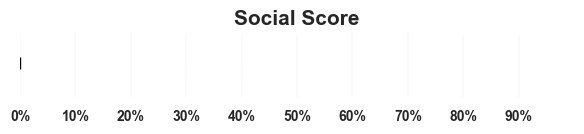

In [274]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, ax = plt.subplots(figsize=(6, 1.5))
# Werte definieren

raw_value = df_user["sc_strava_social_score"][0]
if raw_value is None or pd.isna(raw_value):
    value = 0
else:
    value = raw_value * 100  # tatsächlicher Schlaf in Stunden
print(value)

gradient = np.linspace(0, 1, 100).reshape(1, -1)

if value > 30:
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", ["#65cbc6", "#66cb92"])
else: 
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", ["#e2545b", "#e16549"])

ax.imshow(
    gradient,
    extent=[0, value, 0.15, 0.45],  # [x_start, x_end, y_start, y_end]
    origin='lower',
    aspect='auto',
    cmap=cmap
)

# Optional: Rahmen um den Verlauf
ax.barh(
    y=0.3,
    width=value,
    height=0.3,
    edgecolor='black',
    facecolor='none',
    linewidth=1.0
)
# Achsenlimits
ax.set_xlim(0, 100)
ax.set_ylim(-0.5, 1)

# Y-Achse komplett entfernen
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# X-Achsenticks als Uhrzeit
ticks = list(range(0, 100,10))
tick_labels = [f"{h}%" for h in ticks]
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=10, fontweight='bold')

# Kein Achsentitel
ax.set_title("Social Score", fontsize=15, fontweight='bold')    
ax.set_xlabel("")  # oder: weglassen
# ax.axvline(goal, color='black', linestyle='--', linewidth=1)
# ax.axvline(up_std, color='red', linestyle=':', linewidth=1)
# ax.axvline(down_std, color='purple', linestyle=':', linewidth=1)
# ax.text(
#     down_std ,   # leicht rechts neben der Linie
#     0.75,            # vertikal mittig
#     "minimum",  # dein Labeltext
#     va='center',    # vertikale Ausrichtung
#     ha='center',      # horizontale Ausrichtung
#     fontsize=12,
#     color='black',
#     bbox=dict(
#         facecolor='white',
#         edgecolor='none',
#         boxstyle='round,pad=0.2'
#     )
    
# )



# Untere Linie (Achsenlinie unten) entfernen
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)

# Optional: Leichte Gitterlinie zur besseren Lesbarkeit
ax.grid(axis='x', linestyle=':', linewidth=0.3, color='gray', alpha=0.4)

plt.tight_layout()
plt.savefig("images/charts/social_score.png", dpi=300, bbox_inches='tight')


57.99999999999999


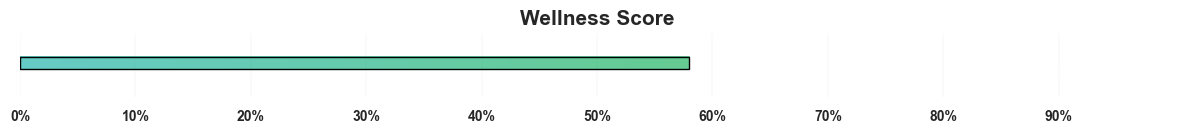

In [275]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
if(pd.isna(df_user["tot_wellness_score"][0])):
    df_user["tot_wellness_score"][0] = 0

fig, ax = plt.subplots(figsize=(12, 1.5))
# Werte definieren

value = df_user["tot_wellness_score"][0] *100  # tatsächlicher Schlaf in Stunden
print(value)

gradient = np.linspace(0, 1, 100).reshape(1, -1)

if value > 50:
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", ["#65cbc6", "#66cb92"])
else: 
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", ["#e2545b", "#e16549"])

ax.imshow(
    gradient,
    extent=[0, value, 0.15, 0.45],  # [x_start, x_end, y_start, y_end]
    origin='lower',
    aspect='auto',
    cmap=cmap
)

# Optional: Rahmen um den Verlauf
ax.barh(
    y=0.3,
    width=value,
    height=0.3,
    edgecolor='black',
    facecolor='none',
    linewidth=1.0
)
# Achsenlimits
ax.set_xlim(0, 100)
ax.set_ylim(-0.5, 1)

# Y-Achse komplett entfernen
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

# X-Achsenticks als Uhrzeit
ticks = list(range(0, 100,10))
tick_labels = [f"{h}%" for h in ticks]
ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels, fontsize=10, fontweight='bold')

# Kein Achsentitel
ax.set_title("Wellness Score", fontsize=15, fontweight='bold')    
ax.set_xlabel("")  # oder: weglassen
# ax.axvline(goal, color='black', linestyle='--', linewidth=1)
# ax.axvline(up_std, color='red', linestyle=':', linewidth=1)
# ax.axvline(down_std, color='purple', linestyle=':', linewidth=1)
# ax.text(
#     down_std ,   # leicht rechts neben der Linie
#     0.75,            # vertikal mittig
#     "minimum",  # dein Labeltext
#     va='center',    # vertikale Ausrichtung
#     ha='center',      # horizontale Ausrichtung
#     fontsize=12,
#     color='black',
#     bbox=dict(
#         facecolor='white',
#         edgecolor='none',
#         boxstyle='round,pad=0.2'
#     )
    
# )



# Untere Linie (Achsenlinie unten) entfernen
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)

# Optional: Leichte Gitterlinie zur besseren Lesbarkeit
ax.grid(axis='x', linestyle=':', linewidth=0.3, color='gray', alpha=0.4)

plt.tight_layout()
plt.savefig("images/charts/wellness_score.png", dpi=300, bbox_inches='tight')


In [276]:
user_secrets= pd.read_csv("data/secret_info.csv")
query = f"""
SELECT user_id FROM dim_user WHERE user_number = {user}
"""
user_id = data_from_data_sink(query).iloc[0, 0]
print(user_id)
print(user_secrets)

user_secrets.loc[user_secrets["user_id"] == user_id,"date_of_birth"].iloc[0]

print(df_user)

26c922720ebebb10511289e3c5de33b90c3fcaf67d6c675aeb87c00b4a6dcb4c
   first_name   last_name place_of_birth date_of_birth  \
0        Dave      Emmert       Würzburg    23.04.2000   
1        Dave      Emmert       Würzburg    23.04.2000   
2        Dave      Emmert       Würzburg    23.04.2000   
3        Dave      Emmert       Würzburg    23.04.2000   
4        Dave      Emmert       Würzburg    23.04.2000   
5        Dave      Emmert       Würzburg    23.04.2000   
6        Dave      Emmert       Würzburg    23.04.2000   
7      Andrei     Abashev            ...    01.01.1900   
8       Gökan       Gorer            ...    01.01.1900   
9       Manoj   KuM Saini            ...    01.01.1900   
10        Seb         ...            ...    01.01.2000   
11        Jen         ...            ...    01.01.2000   

                     email                street number p_code    city  \
0   David.Emmert@online.de  Johann-Georg-Strasse      3  10709  Berlin   
1   David.Emmert@online.de  Joha

/Users/dave/Desktop/BIPM/WHO_AM_I/sports-buddies/sports-buddies/functions.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [289]:
import time
from datetime import datetime  
print(df_user["pa_t3"][0])

def is_valid(val):
    if not isinstance(val, str):
        return False
    val = val.strip().lower()
    return val not in ["none", "na", ""]


def map_activity(activity):
    activity_lower = activity.lower()
    if not is_valid(activity_lower):
        return None
    if "ride" in activity_lower or "rad" in activity_lower:
        return "cycling"
    elif "walking" in activity_lower or "walk" in activity_lower:
        return "walking"
    elif "swimming" in activity_lower or "schwimm" in activity_lower:
        return "swimming"
    elif "run" in activity_lower or "lauf" in activity_lower:
        return "running"
    elif "hiking" in activity_lower or "wandern" in activity_lower:
        return "hiking"
    else:
        return "other_training"

 #Check if all activities are None
all_none = all(df_user[f"pa_t{i}"][0] is None for i in range(1, 5))
if all_none:
    pa_1 = "fauler_hund"
    pa_2 = pa_3 = pa_4 = "other_training"
    var_occ_pa_2 = "opacity: 0;"
    var_occ_pa_3 = "opacity: 0;"
    var_occ_pa_4 = "opacity: 0;"
else:
    pa_1 = map_activity(df_user["pa_t1"][0].split("\n")[0]) if df_user["pa_t1"][0] is not None else None
    pa_2 = map_activity(df_user["pa_t2"][0].split("\n")[0]) if df_user["pa_t2"][0] is not None else None
    pa_3 = map_activity(df_user["pa_t3"][0].split("\n")[0]) if df_user["pa_t3"][0] is not None else None
    pa_4 = map_activity(df_user["pa_t4"][0].split("\n")[0]) if df_user["pa_t4"][0] is not None else None
    var_occ_pa_2 = "opacity: 1;" if pa_2 is not None else "opacity: 0;"
    var_occ_pa_3 = "opacity: 1;" if pa_3 is not None else "opacity: 0;"
    var_occ_pa_4 = "opacity: 1;" if pa_4 is not None else "opacity: 0;"

var_event_dog_true = True#df_user["sc_strava_event_dog"][0] 
var_event_dog = "event_dog" if var_event_dog_true else "no_event_dog"
print(var_event_dog_true)
if var_event_dog_true:
    var_event_dog_true = "opacity: 1;"
else:
    var_event_dog_true = "opacity: 0;"

print(pa_3)

NA
True
None


In [290]:


f_name = user_secrets.loc[user_secrets["user_id"] == user_id,"first_name"].iloc[0]
l_name = user_secrets.loc[user_secrets["user_id"] == user_id,"last_name"].iloc[0]
var_name = f"{f_name} {l_name}"
# 1. Geburtsdatum
print(user_id)
var_date_birth =user_secrets.loc[user_secrets["user_id"] == user_id,"date_of_birth"].iloc[0]
dob = datetime.strptime(var_date_birth, "%d.%m.%Y")
# 2. Alter berechnen
today = datetime.today()
var_age = (today - dob).days // 365
var_place_birth = user_secrets.loc[user_secrets["user_id"] == user_id,"place_of_birth"].iloc[0]
street = user_secrets.loc[user_secrets["user_id"] == user_id,"street"].iloc[0]
number = user_secrets.loc[user_secrets["user_id"] == user_id,"number"].iloc[0]
var_street_number = f"{street} {number}"
city= user_secrets.loc[user_secrets["user_id"] == user_id,"city"].iloc[0]
print(pa_1, pa_2, pa_3, pa_4)   
# Wake-ups
var_wake_ups = round(df_user["sleep_wakeups_avg"][0], 0) if df_user["sleep_wakeups_avg"][0] is not None else 0

# Motivation
motivation_type_val = df_user["motivation_type"][0]
print(motivation_type_val)

if motivation_type_val is not None:
    var_motivation = motivation_type_val.split("\n")[0].lower()
else:
    var_motivation = "not maintained"

# Strava Event Dog
var_event_dog_true = df_user["sc_strava_event_dog"][0] if df_user["sc_strava_event_dog"][0] is not None else False
var_event_dog = "strava_event_dog" if var_event_dog_true else "empty"
print(var_event_dog_true)

var_event_dog_title = "Event Dog!" if var_event_dog_true else ""
var_event_dog_true = "opacity: 1;" if var_event_dog_true else "opacity: 0;"


26c922720ebebb10511289e3c5de33b90c3fcaf67d6c675aeb87c00b4a6dcb4c
cycling other_training None None
Performance
False


In [291]:
user_vars = {
    "var_name": var_name,
    "var_date_birth": var_date_birth,
    "var_age": var_age,
    "var_place_birth": var_place_birth,
    "var_street_number": "Stephanstraße 3", #var_street_number,
    "city": city,
    "pa_1": pa_1,
    "pa_2": pa_2,
    "pa_3": pa_3,
    "pa_4": pa_4,
    "var_occ_pa_2": var_occ_pa_2,
    "var_occ_pa_3": var_occ_pa_3,
    "var_occ_pa_4": var_occ_pa_4,
    "var_wake_ups": var_wake_ups,
    "var_motivation": var_motivation,
    "var_event_dog_true": var_event_dog_true,
    "var_event_dog": var_event_dog,
    "var_event_dog_title" : var_event_dog_title 
}

In [292]:
print(user_vars)

{'var_name': 'Andrei Abashev', 'var_date_birth': '01.01.1900', 'var_age': 125, 'var_place_birth': '...', 'var_street_number': 'Stephanstraße 3', 'city': '...', 'pa_1': 'cycling', 'pa_2': 'other_training', 'pa_3': None, 'pa_4': None, 'var_occ_pa_2': 'opacity: 1;', 'var_occ_pa_3': 'opacity: 0;', 'var_occ_pa_4': 'opacity: 0;', 'var_wake_ups': np.float64(nan), 'var_motivation': 'performance', 'var_event_dog_true': 'opacity: 0;', 'var_event_dog': 'empty', 'var_event_dog_title': ''}


In [293]:
from jinja2 import Environment, FileSystemLoader
import os
output_file = f"rendered_profiles/health_{f_name}_{l_name}.html"
env = Environment(loader=FileSystemLoader("templates"))
template = env.get_template("health_tmpl.html")

# Rendern
output = template.render(user_vars)
os.makedirs("rendered_profiles", exist_ok=True)
#env = Environment(loader=FileSystemLoader("rendered_profiles"))
with open(output_file, "w", encoding="utf-8") as f:
    f.write(output)

print(f"✅ Template erfolgreich gerendert als {output_file}")

✅ Template erfolgreich gerendert als rendered_profiles/health_Andrei_Abashev.html
